## Предсказания TLM для SeniorTalk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from datetime import datetime

In [2]:
PREDICTIONS_PATH = "/home/ext-ivanova-mk@ad.speechpro.com/test_dir/tlm/feature_extraction/seniortalk_titanet_embeddings/seniortalk_titanet_metadata_with_predictions.csv"
SPKRINFO_PATH = "/home/ext-ivanova-mk@ad.speechpro.com/ITMO/datasets--evan0617--seniortalk/snapshots/d8f71863fff5d3128f806ca9025c653dd3dac397/SPKINFO.txt"

df_preds = pd.read_csv(PREDICTIONS_PATH)
df_preds.head()

,file_name,speaker_id,embedding_path,embedding_dim,age_pred
0,Elderly0060S0196W0120.wav,60,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,26.000000
1,Elderly0060S0196W0121.wav,60,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,30.898590
2,Elderly0060S0196W0126.wav,60,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,29.000000
3,Elderly0060S0196W0130.wav,60,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.000000
4,Elderly0060S0196W0139.wav,60,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,30.752395


In [3]:
df_speakers = pd.read_csv(SPKRINFO_PATH, sep='\t', header=0)
df_speakers.head()

,SPEAKER_ID,GENDER,AGE,city DEVICE
0,1,M,81,北京 HUAWEI MGA-AL00
1,2,F,78,北京 HUAWEI MGA-AL00
2,3,F,77,浙江 HONOR AL10
3,4,F,76,浙江 HONOR AL10
4,5,F,76,北京 Iphone 13pro


In [4]:
def extract_speaker_id(filename):
    match = re.search(r'Elderly(\d+)S', filename)
    if match:
        return int(match.group(1))
    return None

df_preds['speaker_id'] = df_preds['file_name'].apply(extract_speaker_id)

print(f"   Извлечено speaker_id для {df_preds['speaker_id'].notna().sum()} из {len(df_preds)} записей")

# Преобразуем speaker_id в df_speakers к int
df_speakers['SPEAKER_ID'] = df_speakers['SPEAKER_ID'].astype(int)

# Объединяем
df = pd.merge(df_preds, df_speakers, left_on='speaker_id', right_on='SPEAKER_ID', how='inner')
print(f"\n   Объединено {len(df)} записей")

df[['file_name', 'speaker_id', 'AGE', 'age_pred', 'GENDER']].head()

   Извлечено speaker_id для 1684 из 1684 записей

   Объединено 1319 записей


,file_name,speaker_id,AGE,age_pred,GENDER
0,Elderly0060S0196W0120.wav,60,78,26.000000,M
1,Elderly0060S0196W0121.wav,60,78,30.898590,M
2,Elderly0060S0196W0126.wav,60,78,29.000000,M
3,Elderly0060S0196W0130.wav,60,78,33.000000,M
4,Elderly0060S0196W0139.wav,60,78,30.752395,M


In [5]:
df = df.rename(columns={'AGE': 'true_age'})

# Вычисление ошибок
df['error'] = df['age_pred'] - df['true_age']
df['abs_error'] = abs(df['error'])
df['squared_error'] = df['error'] ** 2

# Основные метрики
MAE = df['abs_error'].mean()
RMSE = np.sqrt(df['squared_error'].mean())
STD_ERROR = df['error'].std()

# Процент ошибок в пределах
within_1_year = (df['abs_error'] <= 1).mean() * 100
within_2_years = (df['abs_error'] <= 3).mean() * 100
within_3_years = (df['abs_error'] <= 5).mean() * 100
within_5_years = (df['abs_error'] <= 10).mean() * 100

print("\nМетрики оценки TLM модели на SeniorTalk")
print("\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print("\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_2_years:.1f}%")
print(f"  ≤ 5 года:  {within_3_years:.1f}%")
print(f"  ≤ 10 лет:   {within_5_years:.1f}%")

print("\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df['abs_error'].max():.3f} лет")


Метрики оценки TLM модели на SeniorTalk

Основные метрики:
MAE  (Mean Absolute Error):     41.566 лет
RMSE (Root Mean Squared Error): 42.292 лет
Std of Error (разброс ошибок):  7.804 лет

Процент ошибок в пределах:
  ≤ 1 год:   0.0%
  ≤ 3 года:  0.0%
  ≤ 5 года:  0.0%
  ≤ 10 лет:   0.0%

Статистика абсолютных ошибок:
  Мин ошибка:  14.018 лет
  Медиана:     43.000 лет
  Макс ошибка: 57.608 лет


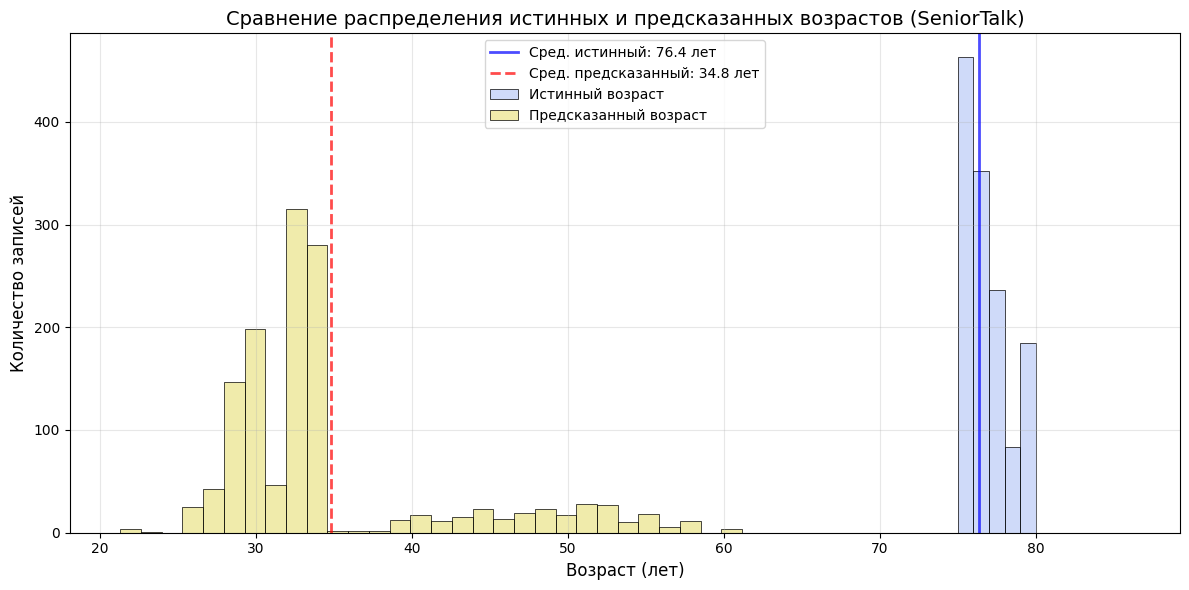

In [6]:
# Сравнение распределений истинного и предсказанного возраста
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='true_age', bins=range(74, 87), 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5, stat='count')

sns.histplot(data=df, x='age_pred', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, stat='count')

plt.axvline(df['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df["true_age"].mean():.1f} лет')
plt.axvline(df['age_pred'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df["age_pred"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов (SeniorTalk)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()